In [ ]:
!pip install pandas

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/X data.csv").copy() #read csv file and print top 5 rows
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [ ]:
#Count sentiments
actual_counts = df['category'].value_counts()

#Calculate percentages
actual_percentages = round((actual_counts / len(df)) * 100, 2)

print("Counts:")
print(actual_counts)

print("\nPercentages:")
print(actual_percentages)

Counts:
category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64

Percentages:
category
 1.0    44.33
 0.0    33.88
-1.0    21.79
Name: count, dtype: float64


In [ ]:
!pip install nltk

In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
df['vader_compound'] = df['clean_text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

def get_vader_label(score):
    if score >= 0.05:
        return 1.0
    elif score <= -0.05:
        return -1.0
    else:
        return 0.0

df['vader_label'] = df['vader_compound'].apply(get_vader_label)

In [ ]:
def convert_label(x):
    if x == 1.0:
        return "Positive"
    elif x == -1.0:
        return "Negative"
    else:
        return "Neutral"

df['clean_data'] = df['category'].apply(convert_label)

In [ ]:
sia = SentimentIntensityAnalyzer()

In [ ]:
vader_counts = df['category'].value_counts()

vader_percentages = round(
    (vader_counts / len(df)) * 100,
    2
)

vader_results = pd.DataFrame({
    'Count': vader_counts,
    'Percentage': vader_percentages
})

print(vader_results)

          Count  Percentage
category                   
 1.0      72250       44.33
 0.0      55213       33.88
-1.0      35510       21.79


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text


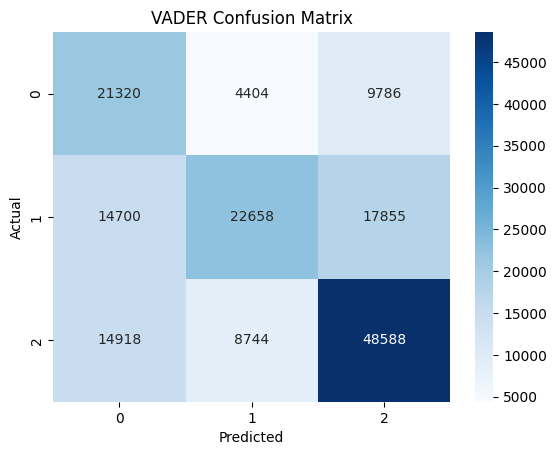

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Drop rows where 'category' column has NaN values and create a proper copy
df_cleaned = df.dropna(subset=['category', 'vader_label']).copy()

cm = confusion_matrix(df_cleaned['category'], df_cleaned['vader_label'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VADER Confusion Matrix")
plt.show()

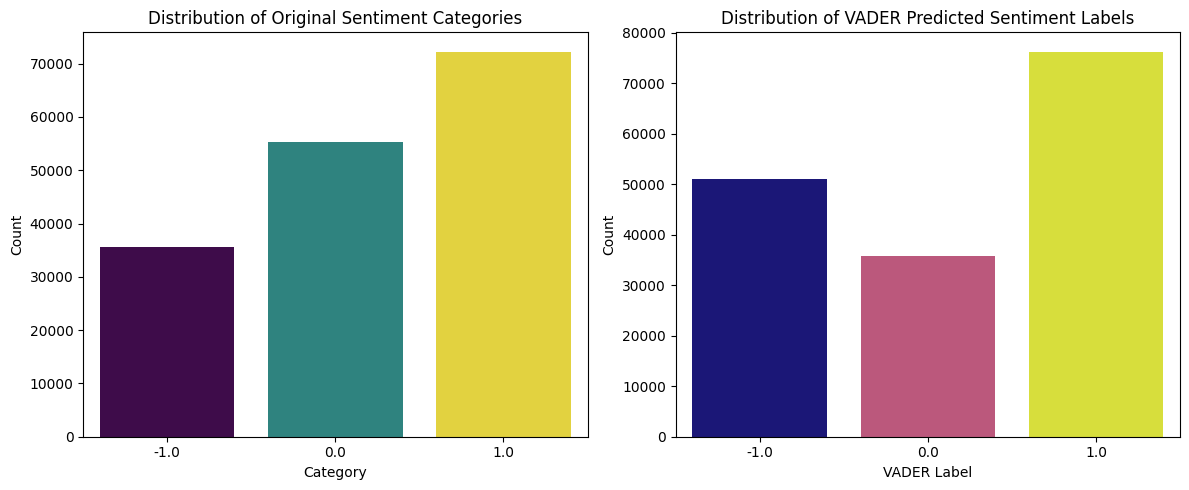

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='category', hue='category', data=df_cleaned, palette='viridis', legend=False)
plt.title('Distribution of Original Sentiment Categories')
plt.xlabel('Category')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='vader_label', hue='vader_label', data=df_cleaned, palette='plasma', legend=False)
plt.title('Distribution of VADER Predicted Sentiment Labels')
plt.xlabel('VADER Label')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

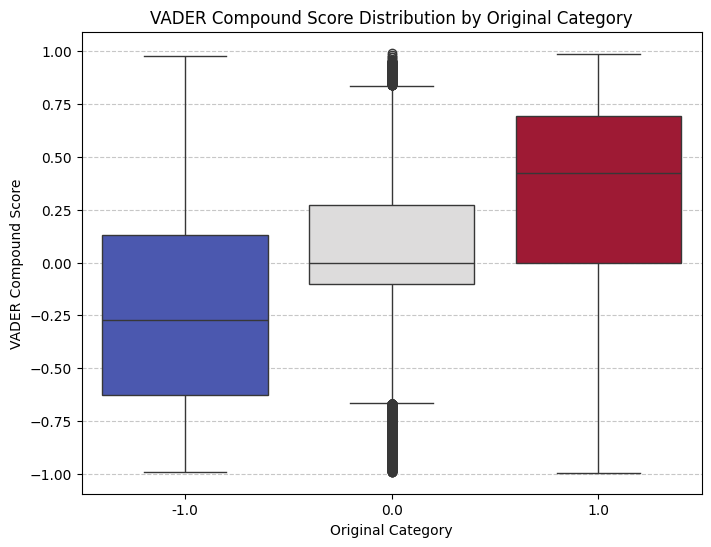

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='category', y='vader_compound', hue='category', data=df_cleaned, palette='coolwarm', legend=False)
plt.title('VADER Compound Score Distribution by Original Category')
plt.xlabel('Original Category')
plt.ylabel('VADER Compound Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

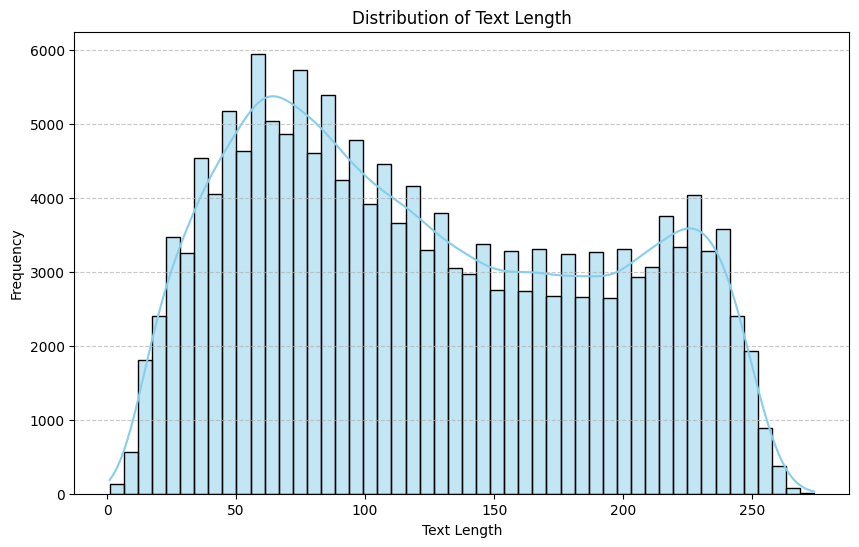

In [ ]:
df_cleaned['text_length'] = df_cleaned['clean_text'].astype(str).apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['text_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Calculate the percentage breakdown of sentiment labels
sentiment_percentage = df_cleaned['vader_label'].value_counts(normalize=True) * 100

# Display the results
print("Percentage Breakdown of VADER Sentiment Labels:")
print(sentiment_percentage)

Percentage Breakdown of VADER Sentiment Labels:
vader_label
 1.0    46.774006
-1.0    31.255484
 0.0    21.970510
Name: proportion, dtype: float64


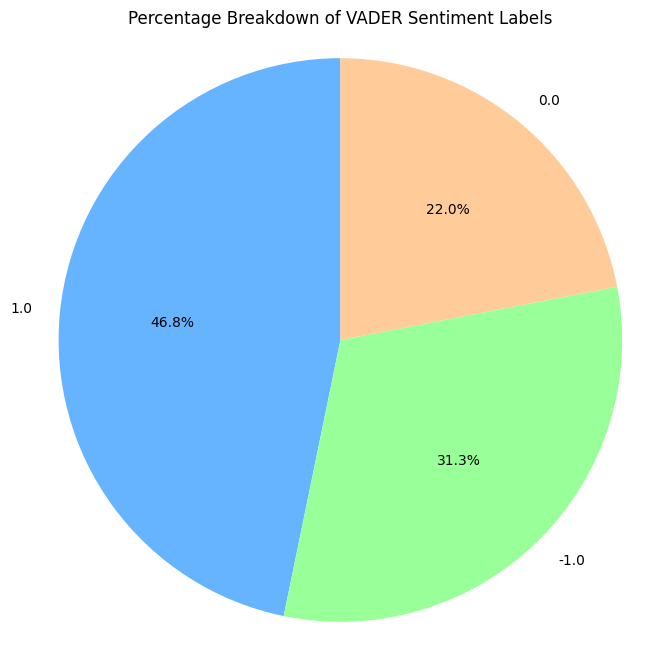

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(sentiment_percentage, labels=sentiment_percentage.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99','#ffcc99'])
plt.title('Percentage Breakdown of VADER Sentiment Labels')
plt.axis('equal')
plt.show()